## 1.1 Contents<a id='1.1_Contents'></a>
* [1. Relax Inc. User Adoption Analysis](#1_Relax_Inc._User_Adoption_Analysis)
  * [1.1 Contents](#1.1_Contents)
  * [1.2 Problem Statement](#1.2_Problem_Statement)
  * [1.3 Imports](#1.3_Imports)
  * [1.4 Load the Data](#1.4_Load_the_Data)
  * [1.5 Data Wrangling](#1.5_Data_Wrangling)
     * [1.5.1 User Data Wrangling](#1.5.1_User_Data_Wrangling)
     * [1.5.2 User Engagement Data Wrangling](#1.5.1_User_Engagement_Data_Wrangling)
     * [1.5.3 Final_Merged_Dataset](#1.5.3_Final_Merged_Dataset)
  * [1.6 Exploratory Data Analysis](#1.6_Exploratory_Data_Analysis)
     * [1.6.1 Categorical Features](#1.6.1_Categorical_Features)
     * [1.6.2 Numerical Features](#1.6.2_Numerical_Features)
     * [1.6.3 User Trends](#1.6.3_User_Trends)
     * [1.6.4 Correlation Analysis](#1.6.4_Correlation_Analysis)
  * [1.7 Modeling](#1.7_Modeling)
    * [1.7.1 Logistic Regression Model](#1.7.1_Logistic_Regression_Model)
  * [1.8 Key Insights](#1.8_Key_Insights)
  * [1.9 Recommendations](#1.9_Recommendations)
  * [1.10 Limitations & Next Steps](#1.10_Limitations_&_Next_Steps)

## 1.2 Problem Statement<a id='1.2_Problem_Statement'></a>

Relax Inc. makes productivity and project management software that's popular with both individuals and teams. Founded by several former Facebook employees, it's considered a great company to work for.

#### They would like to identify which factors predict future user adoption. 

An "adopted user" is defined as a user who has logged into the product on three separate days in at least one sevenday period.

Two data sets described below have been provided for this exercise to help understand what factors are the best predictors for user adoption to help Relax Inc. increase customer retention.

##### takehome_user_engagement.csv : 
Usage summary table ( "takehome_user_engagement" ) that has a row for each day that a user logged into the product.
##### takehome_users.csv : 
user table with data on 12,000 users who signed up for the product in the last two years.

## 1.3 Imports<a id='1.3_Imports'></a>

Let's import the necessary packages to perform the analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import os

## 1.4 Load the Data<a id='1.4_Load_the_Data'></a>

Lets load the csv data files into pandas dataframe.

In [2]:
rd_users = pd.read_csv('takehome_users.csv', encoding = 'latin-1')
rd_eng = pd.read_csv('takehome_user_engagement.csv')

In [3]:
#Quick Dataframes Inspection to check data got loaded properly
rd_users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [4]:
rd_eng.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


## 1.5 Data Wrangling<a id='1.5_Data_Wrangling'></a>

In this section, we will do data inspection, cleaning, any restructuring for the next steps of Exploratory Data Analysis and Modeling.

### 1.5.1 User Data Wrangling<a id='1.5.1_User_Data_Wrangling'></a>

In [5]:
rd_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


The data contains 12000 entries and there are some nulls in last_session_creation_time & invited_by_user_id columns.  
creation_time and last_session_creation_time contain dates but are currently stored with a different data type. Lets first convert them to dates.

In [6]:
rd_users['creation_time']=pd.to_datetime(rd_users['creation_time'])
rd_users['last_session_creation_time'] = pd.to_datetime(rd_users['last_session_creation_time'],unit='s')

In [7]:
#lets check whether they got converted properly
rd_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  object        
 3   email                       12000 non-null  object        
 4   creation_source             12000 non-null  object        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          6417 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(4), object(3)
memory usage: 937.6+ KB


In [8]:
rd_users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,5240.0


timestamps looks good. Lets inspect and remove any duplicate records.

In [9]:
rd_users.duplicated().sum()

np.int64(0)

Great! There are no duplicates. Next, lets handle nulls for invited_by_user_id. Lets inspect missing values.

In [10]:
rd_users[rd_users['invited_by_user_id'].isna()].groupby('creation_source').size()

creation_source
PERSONAL_PROJECTS     2111
SIGNUP                2087
SIGNUP_GOOGLE_AUTH    1385
dtype: int64

The only missing values for invited_by_user_id are for self signups. So, that is not an issue. We will leave the missing values as they are.
Last session creation time is a secondary time stamp for our project so we will leave the missing values for this field as they are as well.

In [11]:
rd_users.describe()

,object_id,creation_time,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,12000.00000,12000,8823,12000.000000,12000.000000,12000.000000,6417.000000
mean,6000.50000,2013-07-16 13:25:32.964499968,2013-09-15 21:08:25.700441856,0.249500,0.149333,141.884583,5962.957145
min,1.00000,2012-05-31 00:43:27,2012-05-31 08:20:06,0.000000,0.000000,0.000000,3.000000
25%,3000.75000,2013-01-15 21:28:22.750000128,2013-03-13 17:16:05,0.000000,0.000000,29.000000,3058.000000
50%,6000.50000,2013-08-05 21:35:19.500000,2013-10-27 15:41:10,0.000000,0.000000,108.000000,5954.000000
75%,9000.25000,2014-01-28 10:20:12.249999872,2014-04-25 16:16:44,0.000000,0.000000,238.250000,8817.000000
max,12000.00000,2014-05-30 23:59:19,2014-06-06 14:58:50,1.000000,1.000000,416.000000,11999.000000
std,3464.24595,NaN,NaN,0.432742,0.356432,124.056723,3383.761968


A quick look at the basic stats for user data tells us that the creation date range is between 2012-05-31 and 2014-05-30 (2 years). ~53% users are based on invitations from users/orgs. ~25% have opted in to mailing list and ~15% are enabled for marketing drip.

Lets look the the user engagement data next.

### 1.5.2 User Engagement Data Wrangling<a id='1.5.2_User_Engagement_Data_Wrangling'></a>

In [12]:
rd_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


This dataset has 207917 user activity records with the user_id and visited datetime. Lets first convert time_stamp field to proper datetime format.

In [13]:
rd_eng['time_stamp']= pd.to_datetime(rd_eng['time_stamp'])

In [14]:
rd_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   time_stamp  207917 non-null  datetime64[ns]
 1   user_id     207917 non-null  int64         
 2   visited     207917 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 4.8 MB


In [15]:
rd_eng.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [16]:
rd_eng.describe()

,time_stamp,user_id,visited
count,207917,207917.000000,207917.0
mean,2013-10-30 05:06:45.648763648,5913.314197,1.0
min,2012-05-31 08:20:06,1.000000,1.0
25%,2013-07-16 20:17:21,3087.000000,1.0
50%,2013-12-03 06:38:34,5682.000000,1.0
75%,2014-03-13 08:00:24,8944.000000,1.0
max,2014-06-06 14:58:50,12000.000000,1.0
std,NaN,3394.941674,0.0


Quick Stats for User Engagement shows that there are 207917 visits spanning roughly a 2 year time period from 2012-05-31 to 2014-06-06. We can also see that the unique count of users, 12000, matches with the users table.

There are no nulls in this data. Let's quickly check for any duplicates.

In [17]:
rd_eng.duplicated().sum()

np.int64(0)

Great! The user engagement data looks clean. Let's create our target variable 'user_adopted' next.

We will first have to define a function to accomplish this.

In [18]:
rd_eng.sort_values(['user_id','time_stamp'])
def user_adoption(t):
    date = t['time_stamp'].dt.date.unique()
    date = sorted(date)
    for i in range(len(date)):
        c=1
        for j in range(i+1, len(date)):
            if (date[j]-date[i]).days<=7:
                c+=1
                if c>=3:
                    return 1
            else:
                break
    return 0

In [19]:
adoption = rd_eng.groupby(['user_id']).apply(user_adoption, include_groups=False).reset_index()
adoption.columns = ['user_id','user_adopted']

In [20]:
#lets quickly check this adoption dataframe
adoption.head()

,user_id,user_adopted
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [21]:
adoption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8823 entries, 0 to 8822
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       8823 non-null   int64
 1   user_adopted  8823 non-null   int64
dtypes: int64(2)
memory usage: 138.0 KB


In [22]:
#Total User Asdoption Count
adoption['user_adopted'].sum()

np.int64(1656)

Overall user adoption rate is 1656 out of 12000 users (13.8%).  
In the next section, we will merge this dataset with the users dataset and create our final table.

### 1.5.3 Final Merged Dataset<a id='1.5.3_User_Engagement_Data_Wrangling'></a>

In [23]:
relax_df = rd_users.merge(adoption, left_on = 'object_id', right_on='user_id', how='left')
relax_df['user_adopted']=relax_df['user_adopted'].fillna(0)

The users who registered in the final few dates of may and partial June 2014 cannot be shown in the adoption rate because they would not even have had one complete 7 day period to show adoption. So, lets drop the records for user created after the cutooff date of last_session_creation_time -7.

In [24]:
cutoff_date = relax_df['last_session_creation_time'].dropna().dt.date.max() - pd.Timedelta(days=7)
relax_df = relax_df[relax_df['creation_time'].dt.date <= cutoff_date]

In [25]:
#Lets create a few more engineered features that will help us with our analysis
relax_df['user_invited'] = relax_df['invited_by_user_id'].notnull().astype('int')
relax_df['org_size'] = relax_df['org_id'].map(relax_df.groupby('org_id').size())
bin_edges=[0,5,25,100,np.inf]
bin_labels=['Tiny','Small','Medium','Large']
relax_df['org_size_bin'] = pd.cut(relax_df['org_size'], bins = bin_edges, labels=bin_labels)

In [26]:
#Lets drop redundant fields like user_id on the merged dataset
relax_df.drop(columns =['user_id'], inplace=True)

In [27]:
relax_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  object        
 3   email                       12000 non-null  object        
 4   creation_source             12000 non-null  object        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          6417 non-null   float64       
 10  user_adopted                12000 non-null  float64       
 11  user_invited                12000 non-null  int64     

It looks like users who used the product atleast once is 8823 and hence last_session_creation_time also has the same number of non null values. So, the nulls dont need any extra treatment.

Lets look at the basic stats for our dataset below.

In [28]:
relax_df.describe(include = 'all')

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,user_adopted,user_invited,org_size,org_size_bin
count,12000.00000,12000,12000,12000,12000,8823,12000.000000,12000.000000,12000.000000,6417.000000,12000.000000,12000.000000,12000.000000,12000
unique,NaN,NaN,11355,11980,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,Araujo Gabriela,AlfieLane@yahoo.com,ORG_INVITE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,NaN,5,2,4254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5408
mean,6000.50000,2013-07-16 13:25:32.964499968,NaN,NaN,NaN,2013-09-15 21:08:25.700441856,0.249500,0.149333,141.884583,5962.957145,0.138000,0.534750,55.108500,NaN
min,1.00000,2012-05-31 00:43:27,NaN,NaN,NaN,2012-05-31 08:20:06,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,2.000000,NaN
25%,3000.75000,2013-01-15 21:28:22.750000128,NaN,NaN,NaN,2013-03-13 17:16:05,0.000000,0.000000,29.000000,3058.000000,0.000000,0.000000,21.000000,NaN
50%,6000.50000,2013-08-05 21:35:19.500000,NaN,NaN,NaN,2013-10-27 15:41:10,0.000000,0.000000,108.000000,5954.000000,0.000000,1.000000,29.000000,NaN
75%,9000.25000,2014-01-28 10:20:12.249999872,NaN,NaN,NaN,2014-04-25 16:16:44,0.000000,0.000000,238.250000,8817.000000,0.000000,1.000000,55.000000,NaN
max,12000.00000,2014-05-30 23:59:19,NaN,NaN,NaN,2014-06-06 14:58:50,1.000000,1.000000,416.000000,11999.000000,1.000000,1.000000,319.000000,NaN


Based on the TOP value for creation_source 'ORG_INVITE', it looks like top percentage of users have been invited by an org. ~ 53% users have been invited overall. As we saw earlier, overall user adoption rate is 13.8% based on the current adoption definition of atleast 3 logins within any 7 day period.

## 1.6 Exploratory Data Analysis<a id='1.6_Exploratory_Data_Analysis'></a>

Let us dive deeper into the categorical and numerical feature analysis

### 1.6.1 Categorical Features<a id='1.6.1_Categorical_Features?'></a>

In [29]:
#Lets check the user adoption by creation source
print(f'{100*relax_df.groupby('creation_source')['user_adopted'].mean().sort_values(ascending=False)}')

creation_source
SIGNUP_GOOGLE_AUTH    17.256318
GUEST_INVITE          17.059639
SIGNUP                14.470532
ORG_INVITE            13.493183
PERSONAL_PROJECTS      8.147797
Name: user_adopted, dtype: float64


It looks like maximum % of signups are self signups via google account (17.3%) followed closely by guest invites (17.1%).  
Lowest signups are from invitations to join another user's personal workspace/projects

So, one key insight is that users invited into group work signups and ones using google streamlined logins adopt more easily.

In [30]:
#Lets check retention rate by org_size
print(f'{100*relax_df.groupby('org_size_bin', observed=False)['user_adopted'].mean().sort_values(ascending=False)}')

org_size_bin
Small     15.989381
Medium    13.609467
Large      8.092144
Tiny       0.000000
Name: user_adopted, dtype: float64


It seems like smaller orgs have higher user adoption.

### 1.6.2 Numerical Features<a id='1.6.2_Numerical_Features'></a>

In [31]:
#Lets check the user adoption by invitation
print(f'{100*relax_df.groupby('user_invited')['user_adopted'].mean().sort_values(ascending=False)}')

user_invited
1    14.695341
0    12.770912
Name: user_adopted, dtype: float64


It looks like invited users show a slightly higher adoption rate(15% vs. 13%)

In [32]:
#checking user adoption by opted_in_to_mailing_list
print(f'{100*relax_df.groupby('opted_in_to_mailing_list')['user_adopted'].mean().sort_values(ascending=False)}')

opted_in_to_mailing_list
1    14.328657
0    13.624250
Name: user_adopted, dtype: float64


Users who opted in to mailing list (sign of user engagement/interest in product) show slightly higher adoption rates.

In [33]:
#checking user adoption by enabled_for_marketing_drip	
print(f'{100*relax_df.groupby('enabled_for_marketing_drip')['user_adopted'].mean().sort_values(ascending=False)}')

enabled_for_marketing_drip
1    14.341518
0    13.704937
Name: user_adopted, dtype: float64


In [ ]:
Again, users on the regular marketing drip show slightly higher adoption rates.

### 1.6.3 User Trends<a id='1.6.3_User_Trends'></a>

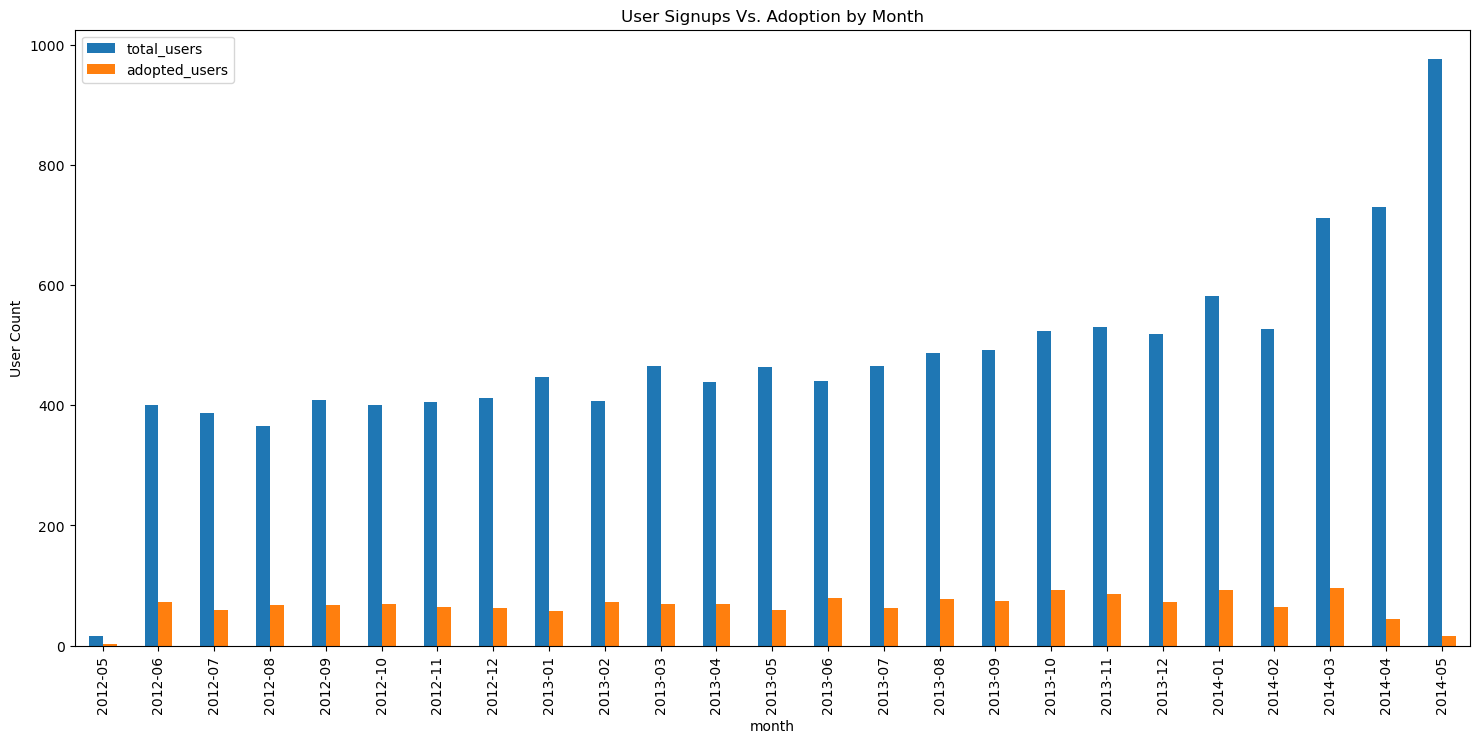

In [55]:
#checking user count and adoption by month-year time period
relax_df['month']=relax_df['creation_time'].dt.to_period('M').astype(str)
monthly_users = relax_df.groupby('month').agg(
                                              total_users = ('object_id', 'count'),
                                              adopted_users = ('user_adopted','sum')
                                              )
monthly_users.plot(kind='bar', figsize=(18,8))
plt.ylabel("User Count")
plt.title('User Signups Vs. Adoption by Month')
plt.savefig('User Signups Vs. Adoption by Month.png', dpi=150)
plt.show()

This chart tells us two key things.  
1. The number of user signups have more thandoubled since 2012 (~ 400 to 950). This is a great sign of produce exposure across the population.
2. However, adoption rate most sits flat at around ~15%/. We will ignore the last 2 months since the users have not had enough time since signup to be judged as adopted or not.

Next lets look at correlation analysis and then define our key features for modeling.

### 1.6.4 Correlation Analysis<a id='1.6.4_Correlation_Analysis'></a>

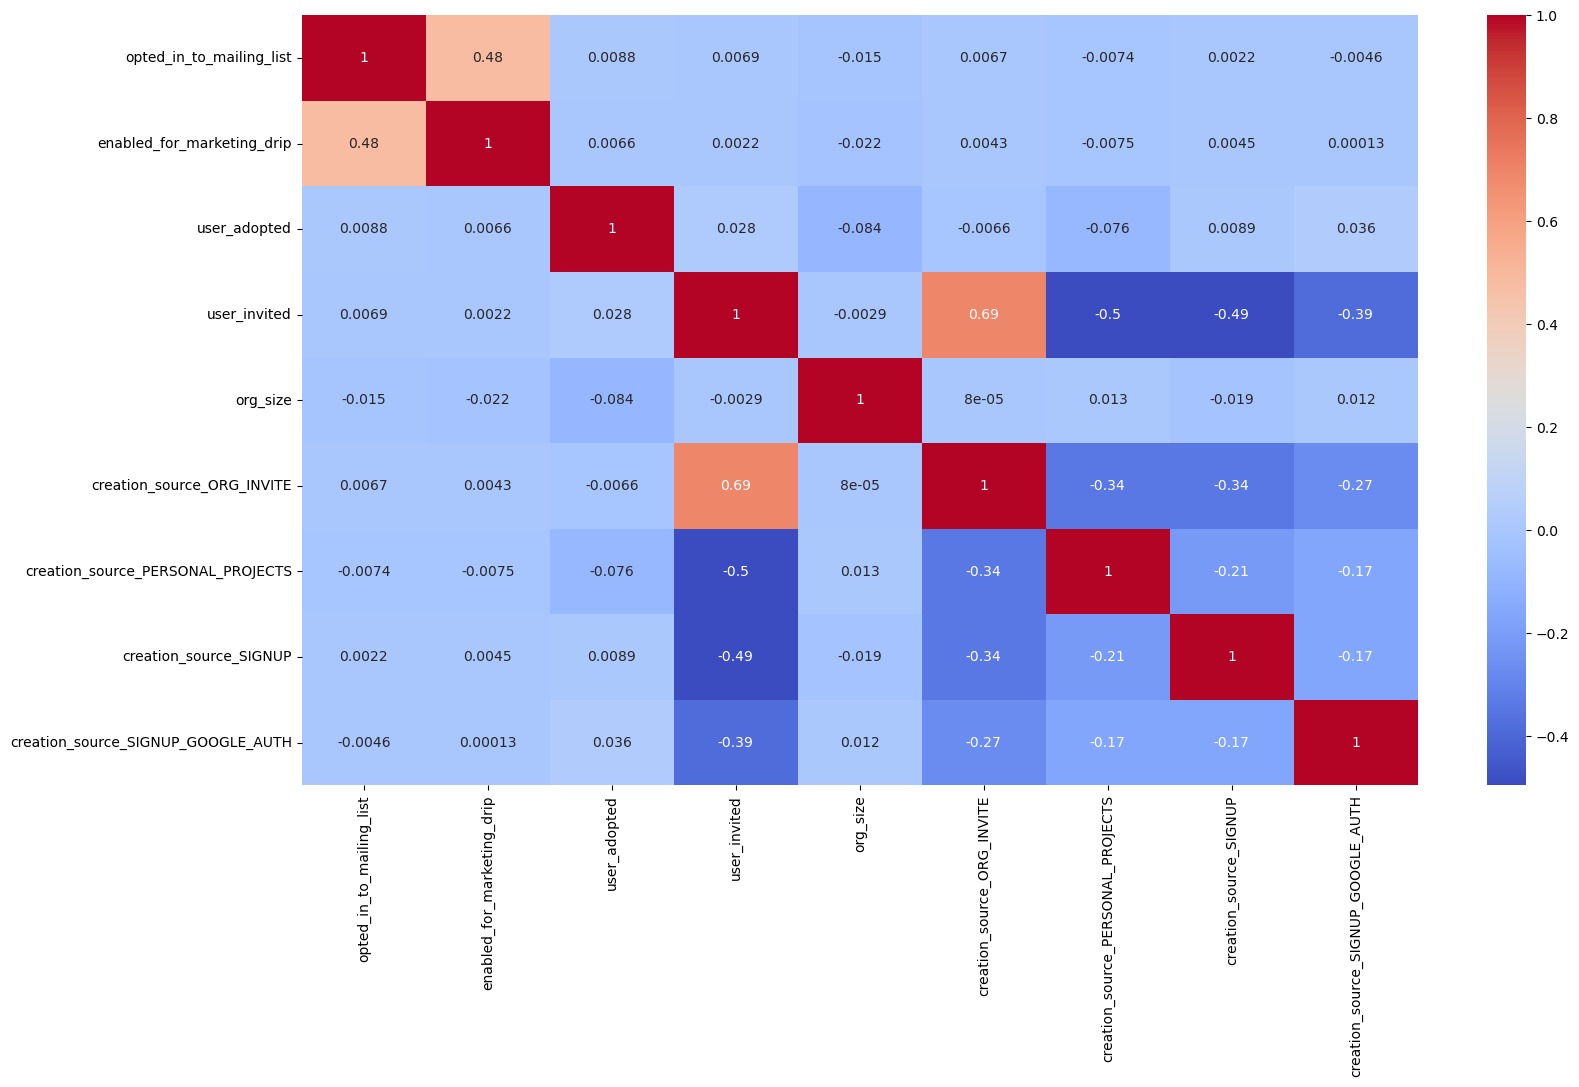

In [56]:
#Let us look at the feature correlations next
#we will encode the categorical features for this exercise as well as modeling using pd.getdummies() function and also drop unnecessary fields
relax_model = relax_df.drop([ 'object_id','creation_time','month','name','email','invited_by_user_id','last_session_creation_time','org_id','org_size_bin'], axis = 1)
relax_model = pd.get_dummies(relax_model, columns = ['creation_source'], drop_first = True)
plt.figure(figsize=(18,10))
sns.heatmap(relax_model.corr(), cmap = 'coolwarm', annot = True)
plt.savefig('Feature Correlations.png', dpi=150)
plt.show()

Based on the correlation heatmap above, it looks like we have very weak feature correlations with user adoption, many of which are statistically significant but small is magnitude.

It looks like there are other external factors not covered in this data that influence user adoption.

We see high collinearity of uer_invited with creation_source fields. So, we will go ahead and drop this for modeling.

In [59]:
relax_model.drop(columns=['user_invited'], inplace=True)

In [41]:
relax_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   opted_in_to_mailing_list            12000 non-null  int64  
 1   enabled_for_marketing_drip          12000 non-null  int64  
 2   user_adopted                        12000 non-null  float64
 3   org_size                            12000 non-null  int64  
 4   creation_source_ORG_INVITE          12000 non-null  bool   
 5   creation_source_PERSONAL_PROJECTS   12000 non-null  bool   
 6   creation_source_SIGNUP              12000 non-null  bool   
 7   creation_source_SIGNUP_GOOGLE_AUTH  12000 non-null  bool   
dtypes: bool(4), float64(1), int64(3)
memory usage: 422.0 KB


Since, we are planning to use logistic regression model, let's quickly check skewness for our only feature with multiple values - org_size.

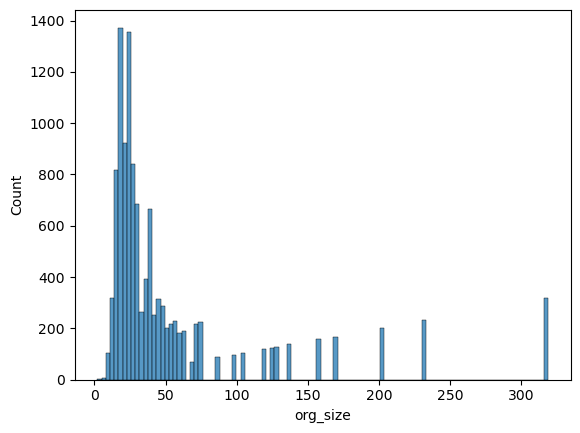

In [42]:
sns.histplot(relax_model['org_size'])
plt.show()

This seems like a heavily right skewed distribution so we will do a log transform on this feature.

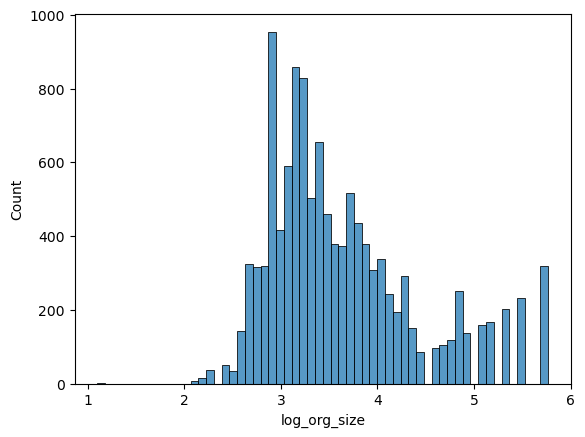

In [44]:
relax_model['log_org_size']=np.log1p(relax_model['org_size'])
sns.histplot(relax_model['log_org_size'])
plt.show()

In [ ]:
This looks much better.

Next, we will drop org_size from the relax_model dataframe.

In [45]:
relax_model.drop(columns =['org_size'], inplace=True)

In [46]:
relax_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   opted_in_to_mailing_list            12000 non-null  int64  
 1   enabled_for_marketing_drip          12000 non-null  int64  
 2   user_adopted                        12000 non-null  float64
 3   creation_source_ORG_INVITE          12000 non-null  bool   
 4   creation_source_PERSONAL_PROJECTS   12000 non-null  bool   
 5   creation_source_SIGNUP              12000 non-null  bool   
 6   creation_source_SIGNUP_GOOGLE_AUTH  12000 non-null  bool   
 7   log_org_size                        12000 non-null  float64
dtypes: bool(4), float64(2), int64(2)
memory usage: 422.0 KB


## 1.7 Modeling<a id='1.7_Modeling'></a>

We will be using Logistic Regression Model for this project for better interpretablity to derive business insights.

In [47]:
#Lets first create the train/test sets (80/20 split)
X = relax_model.drop(['user_adopted'], axis =1)
y = relax_model['user_adopted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

### 1.7.1 Logistic Regression Model<a id='1.7.1_ Logistic_Regression_Model'></a>

In [60]:
#Build the pipeline and fit the model
log_model = Pipeline([
                      ('scaler',StandardScaler()),
                      ('model', LogisticRegression(max_iter = 1000, class_weight='balanced'))
                    ])
log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [61]:
#Lets look at predictions on test set and model performance
pred = log_model.predict(X_test)
prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Model Performance")
print(f"-"*55)
print(classification_report(y_test, pred, zero_division=0))
print(f"ROC_AUC_Score: {round(roc_auc_score(y_test, prob),4)}")

Logistic Regression Model Performance
-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.90      0.49      0.64      2069
         1.0       0.18      0.67      0.28       331

    accuracy                           0.52      2400
   macro avg       0.54      0.58      0.46      2400
weighted avg       0.80      0.52      0.59      2400

ROC_AUC_Score: 0.6051


Interpretation of Logistic Regression Model Performance

1.	Our model predicts most adopters (recall = 0.67). However, the precision is very low(0.18) - meaning roughly 5 out of 6 users that get flagged as "adopted" don’t actually adopt the product.  
2.	Overall Accuracy  is also quite low (52%).  
3.	AUC is ~0.60 which is the model's underlying ability to rank adopters vs. non-adopters (catching more true adopters vs. avoiding false alarms). Whether that tradeoff is worth it depends on the cost of a missed adopter vs. a wasted outreach to a non-adopter.  

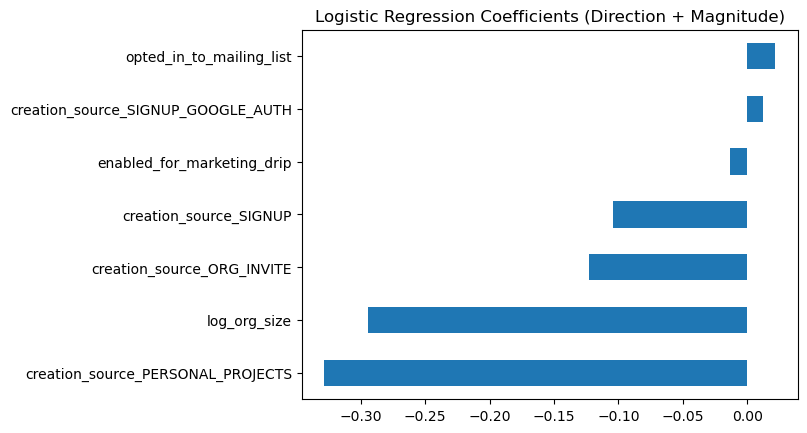

In [62]:
#Lets look at Feature Importance
coef = pd.Series(log_model.named_steps['model'].coef_[0], index = X.columns)
coef.sort_values().plot(kind = 'barh')
plt.title("Logistic Regression Coefficients (Direction + Magnitude)")
plt.savefig('Logistic Regression Coefficients (Direction + Magnitude).png', dpi=150)
plt.show()

1. log_org_size and PERSONAL_PROJECTS are the only dominant drivers, both negative (~-0.3 each) — bigger orgs and personal-project signups adopt worst. 2. Creation source matters - invited users and google signup users are more likely to adopt the product.
3. Users who opt for mailing list also show higher adoption.

## 1.8 Key Insights<a id='1.8_Key Insights'></a>

##### 1.	Overall adoption is low: 13.8% (1,656 of 12,000 users) met the 3-logins-in-7-days adoption criteria.  
##### 2.	Creation source is the clearest EDA signal: SIGNUP_GOOGLE_AUTH (17.3%) and GUEST_INVITE (17.1%) adopt best; PERSONAL_PROJECTS adopts worst (8.1%) - nearly half the average rate.  
##### 3.	Smaller orgs adopt better: Small orgs 16.0%, Medium 13.6%, Large 8.1%.  
##### 4.	Mailing-list opt-in, and marketing drip show marginal impact on adoption rate, directionally positive, but too small to be practically meaningful on their own.  
##### 5.	Signups more than doubled (~ 400 → 950/month) while the adoption rate stayed roughly flat around 15% — growth isn't currently degrading adoption quality, but it isn't improving it either.  
##### 6.	The correlation heatmap confirmed all feature relationships with user_adopted are weak, even where statistically significant — pointing to real drivers outside this dataset (actual product usage, use case) that aren't captured here.  
##### 7.	The logistic regression model (class_weight='balanced') reaches AUC ≈ 0.605 — a real but modest ability to rank adopters vs. non-adopters. At the default threshold it catches most adopters (recall 0.67) but with very low precision (0.18) - 5 of every 6 flagged users don't actually adopt.  
##### 8.	log_org_size and creation_source_PERSONAL_PROJECTS are the two dominant coefficients (~-0.3 each) identified by Logistic Regression model, consistent with the EDA; invited and Google-auth users have a positive impact on adoption rate per the logit model.  

## 1.9 Recommendations<a id='1.9_Recommendations'></a>

##### 1. Prioritize user adoption efforts toward the channels that already convert well — guest invites and Google-auth signups — understanding why they could inform improvements elsewhere.  
##### 2. Investigate the PERSONAL_PROJECTS and large-org segments specifically — both adopt at roughly half the average rate. A targeted onboarding flow or re-engagement nudge for these groups is a more promising lever than broad-based marketing.  
##### 3. De-prioritize marketing drips as adoption lever — the observed impact on adoption rate isn’t large enough to justify being a primary strategy for adoption specifically, even though it may serve other goals.  
##### 4. Don't treat growth and adoption as the same success metric — signups are scaling well, but since adoption rate isn't rising alongside it, sustained growth alone won't translate into a proportionally larger engaged user base.  
##### 5. Use the current model as a directional risk-flag, not a precision targeting tool — given 18% precision, treat "predicted adopted" as "worth a closer look," not as a reliable accurate indicator.  

## 1.10 Limitations & Next Steps<a id='1.10_Limitations_&_Next_Steps'></a>

##### Limitations
1. More non linear models like Random Forest need to be looked at for this data since our current baseline logistic regression model is only directionally accurate.  
2. The feature set is limited to signup-time attributes; as the correlation analysis itself notes, adoption is likely driven substantially by factors not in this data (actual in-product behavior, team context, use case etc).  
##### Next Steps:
1.	Build out the planned Random Forest model to check for non-linear/interaction effects the logistic model can't capture, and compare AUC/feature importance against the logistic results.  
2.	Add cross-validation (e.g., 5-fold) to get a more robust performance estimate than a single split.  
3.	If available, pull in product-usage data (feature-level engagement) to explain more of the currently-unexplained variance.  